# Tech Challenge Fase 1 — NPS Preditivo
## Pós-Graduação em IA Science — FIAP / Pos Tech

---

**Objetivo:** Analisar dados operacionais de um e-commerce para entender os fatores que influenciam a satisfação do cliente (NPS) e construir um modelo preditivo capaz de antecipar a classificação do cliente antes da aplicação da pesquisa.

**Estrutura do notebook:**
1. Entendimento do Negócio (Requisito 1)
2. Definição da Target (Requisito 2)
3. Análise Exploratória dos Dados — EDA (Requisito 3)
4. Modelo Preditivo (Requisito 4 — opcional)

---
## 1. Entendimento do Negócio (Requisito 1)

### 1.1 Qual problema de negócio está sendo resolvido?

A empresa de e-commerce enfrenta um desafio comum em operações de grande escala: **a satisfação do cliente só é medida após o encerramento da jornada de compra**, por meio da pesquisa de NPS. Isso significa que a empresa sempre age de forma reativa — quando o cliente já teve uma experiência ruim, já é tarde para corrigir.

O problema central é: **como transformar dados operacionais já existentes (pedidos, entregas, atendimento) em sinais preditivos de satisfação**, permitindo que a empresa atue de forma proativa antes que o cliente se torne um detrator?

### 1.2 Por que o NPS é importante para um e-commerce?

O Net Promoter Score é a métrica padrão de mercado para medir lealdade do cliente. Ele classifica os clientes em três grupos:
- **Promotores (9-10):** clientes leais que recomendam a marca
- **Neutros (7-8):** satisfeitos mas vulneráveis à concorrência
- **Detratores (0-6):** insatisfeitos que podem prejudicar a marca

Para e-commerce, o NPS é especialmente crítico porque:
- O **custo de aquisição de cliente (CAC)** é alto — perder um cliente adquirido é caro
- A **rentabilidade está na recorrência** — retenção é mais barata que aquisição
- **Reviews e avaliações** são decisivos na jornada de compra online

### 1.3 Quais áreas se beneficiam desses insights?

| Área | Benefício esperado |
|------|-------------------|
| **Logística** | Identificar limiares de atraso que disparam insatisfação e redefinir SLAs |
| **Atendimento** | Alocar equipe de forma inteligente para perfis de maior risco |
| **Produto/Pricing** | Calibrar descontos e condições de pagamento com base no impacto no NPS |
| **CX/Estratégia** | Implementar ações proativas (contato, cupom) para clientes com NPS previsto baixo |

### 1.4 Reflexão — Impacto do NPS no negócio

**Recompra:** Promotores têm probabilidade significativamente maior de recompra. A variável `repeat_purchase_30d` tem correlação de 0.57 com o NPS — clientes satisfeitos compram de novo.

**Boca a boca:** Detratores deixam avaliações negativas que têm peso desproporcional. Em e-commerce, uma avaliação negativa pode afastar dezenas de potenciais compradores.

**Market share:** Em mercados competitivos (Mercado Livre, Amazon, Shopee), a experiência do cliente é o principal diferencial sustentável. Empresas com NPS alto crescem organicamente; as com NPS baixo dependem de investimento crescente em mídia paga.

**Indicadores complementares sugeridos:**
- Benchmarks de NPS do setor de e-commerce brasileiro (líderes entre 40-60)
- SLA logístico prometido vs. praticado
- Taxa de churn correlacionada com faixas de NPS
- CSAT (satisfação pontual) vs. NPS (lealdade de longo prazo)
- First Contact Resolution (FCR) do atendimento

---
## 2. Definição da Target (Requisito 2)

### 2.1 Qual variável representa a satisfação do cliente?

A variável **`nps_score`** (nota de 0 a 10).

### 2.2 Por que ela foi escolhida?

- É a métrica oficial já coletada pela empresa
- É padronizada e comparável com benchmarks de mercado
- Sintetiza a experiência completa do cliente em um único valor
- Permite abordagem de regressão (nota contínua) ou classificação (Promotor/Neutro/Detrator)

### 2.3 Em que momento da jornada essa informação é coletada?

O NPS é coletado **após o encerramento da jornada de compra** (pós-entrega). Todas as variáveis operacionais (entrega, atendimento, reclamações) já ocorreram antes da coleta — são candidatas legítimas a variáveis preditoras.

### 2.4 Riscos de uso inadequado

| Risco | Descrição |
|-------|----------|
| **Viés de resposta** | Quem responde tende a estar nos extremos (muito satisfeito ou muito insatisfeito) |
| **Subjetividade da escala** | Um "7" pode ter significados diferentes para clientes diferentes |
| **Data leakage** | `csat_internal_score` e `repeat_purchase_30d` são consequências do NPS, não causas |
| **Temporalidade** | Nenhuma feature deve ter sido gerada após a coleta do NPS |

---
## 3. Análise Exploratória dos Dados — EDA (Requisito 3)

Nesta seção, exploramos os dados com foco em responder às perguntas de negócio, usando linguagem acessível para um público não técnico.

In [1]:
# ============================================================
# IMPORTACOES E CONFIGURACOES
# ============================================================

# Bibliotecas de manipulacao e analise de dados
import pandas as pd
import numpy as np

# Bibliotecas de visualizacao
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Configuracoes globais dos graficos
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('viridis')

# ============================================================
# CARREGAMENTO DA BASE DE DADOS
# ============================================================
# O CSV esta na pasta data/ conforme estrutura do repositorio
df = pd.read_csv('../data/desafio_nps_fase_1.csv')

print(f'Base carregada: {df.shape[0]} registros, {df.shape[1]} variaveis')
print(f'Valores nulos: {df.isnull().sum().sum()}')
df.head()

Base carregada: 2500 registros, 19 variaveis
Valores nulos: 0


,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


### 3.1 Visão geral da base

In [2]:
# Estatisticas descritivas: media, desvio, min/max e quartis de cada variavel numerica
# Permite identificar outliers e a amplitude de cada feature
df.describe().round(2)

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,1250.50,43.40,61.32,51250.50,434.26,3.47,29.75,6.00,8.02,2.19,38.22,2.01,1.52,5.49,4.38,0.09,4.15,2.94
std,721.83,14.89,34.48,721.83,289.77,1.69,29.23,3.16,3.77,1.45,12.08,0.82,1.23,3.46,2.51,0.28,1.78,2.38
min,1.00,18.00,1.00,50001.00,7.76,1.00,0.02,1.00,2.00,0.00,2.62,1.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,625.75,31.00,31.00,50625.75,220.24,2.00,8.88,3.00,5.00,1.00,29.93,1.00,1.00,2.00,2.60,0.00,3.00,0.70
50%,1250.50,43.00,62.00,51250.50,375.52,3.00,20.94,6.00,8.00,2.00,38.50,2.00,1.00,6.00,4.40,0.00,4.00,2.80
75%,1875.25,56.00,91.00,51875.25,577.29,5.00,40.83,9.00,11.00,3.00,46.27,3.00,2.00,8.00,6.10,0.00,5.00,4.80
max,2500.00,69.00,119.00,52500.00,1983.81,6.00,230.33,11.00,14.00,8.00,76.13,3.00,7.00,11.00,10.00,1.00,11.00,10.00


In [3]:
# Verificacao dos tipos de dados de cada coluna
# Importante identificar variaveis categoricas que precisarao de encoding
df.dtypes

customer_id                    int64
customer_age                   int64
customer_region                  str
customer_tenure_months         int64
order_id                       int64
order_value                  float64
items_quantity                 int64
discount_value               float64
payment_installments           int64
delivery_time_days             int64
delivery_delay_days            int64
freight_value                float64
delivery_attempts              int64
customer_service_contacts      int64
resolution_time_days           int64
nps_score                    float64
repeat_purchase_30d            int64
complaints_count               int64
csat_internal_score          float64
dtype: object

### 3.2 Distribuição do NPS

Primeiro, vamos entender como o NPS se distribui na base e qual a proporção de Promotores, Neutros e Detratores.

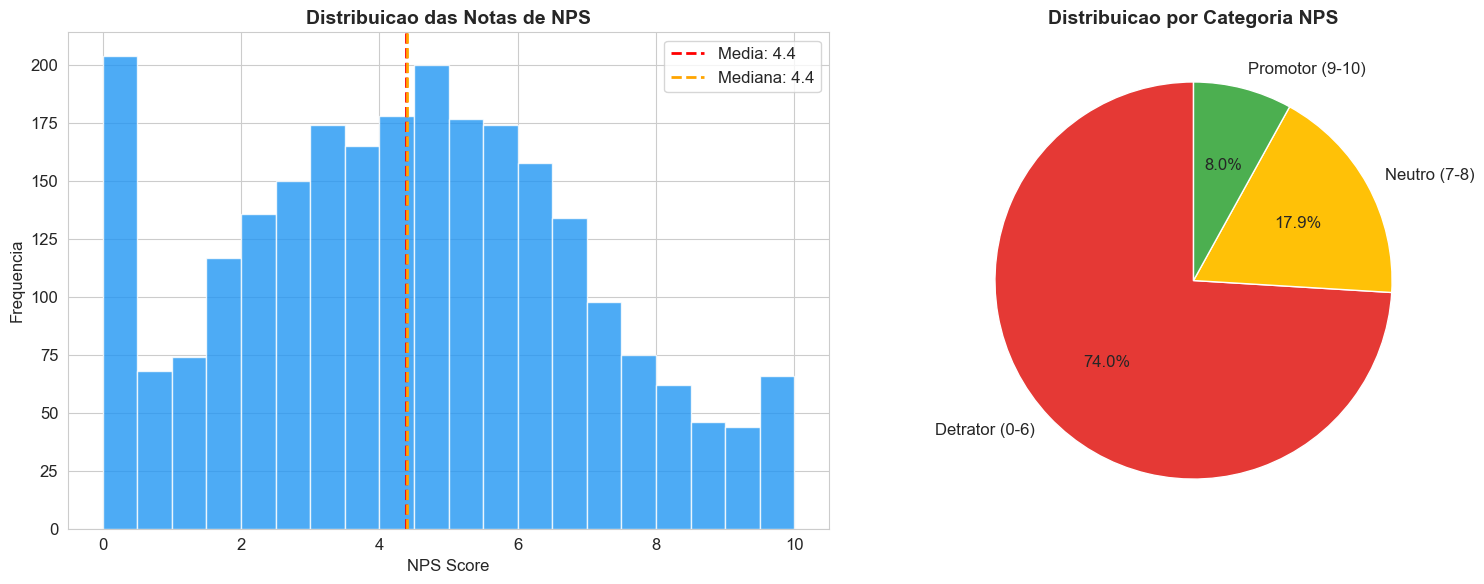


--- Resumo ---
NPS Medio: 4.38
Detratores: 1851 (74.0%)
Neutros: 448 (17.9%)
Promotores: 201 (8.0%)


In [4]:
# ============================================================
# CLASSIFICACAO DO NPS EM CATEGORIAS DE NEGOCIO
# ============================================================

# Funcao que aplica a logica oficial do NPS:
# Detratores = 0 a 6 | Neutros = 7 a 8 | Promotores = 9 a 10
def classificar_nps(score):
    if score <= 6:
        return 'Detrator (0-6)'
    elif score <= 8:
        return 'Neutro (7-8)'
    else:
        return 'Promotor (9-10)'

# Cria coluna com a categoria de cada cliente
df['nps_categoria'] = df['nps_score'].apply(classificar_nps)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Grafico 1: Histograma da distribuicao das notas ---
# Mostra como as notas se distribuem e onde estao media e mediana
axes[0].hist(df['nps_score'], bins=20, color='#2196F3', edgecolor='white', alpha=0.8)
axes[0].axvline(df['nps_score'].mean(), color='red', linestyle='--', linewidth=2,
                label=f'Media: {df["nps_score"].mean():.1f}')
axes[0].axvline(df['nps_score'].median(), color='orange', linestyle='--', linewidth=2,
                label=f'Mediana: {df["nps_score"].median():.1f}')
axes[0].set_title('Distribuicao das Notas de NPS', fontsize=14, fontweight='bold')
axes[0].set_xlabel('NPS Score')
axes[0].set_ylabel('Frequencia')
axes[0].legend()

# --- Grafico 2: Pizza com proporcao por categoria ---
cores = {'Detrator (0-6)': '#E53935', 'Neutro (7-8)': '#FFC107', 'Promotor (9-10)': '#4CAF50'}
contagem = df['nps_categoria'].value_counts()
axes[1].pie(contagem, labels=contagem.index, autopct='%1.1f%%', startangle=90,
            colors=[cores[c] for c in contagem.index], textprops={'fontsize': 12})
axes[1].set_title('Distribuicao por Categoria NPS', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/01_distribuicao_nps.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n--- Resumo ---')
print(f'NPS Medio: {df["nps_score"].mean():.2f}')
print(f'Detratores: {(df["nps_categoria"] == "Detrator (0-6)").sum()} ({(df["nps_categoria"] == "Detrator (0-6)").mean()*100:.1f}%)')
print(f'Neutros: {(df["nps_categoria"] == "Neutro (7-8)").sum()} ({(df["nps_categoria"] == "Neutro (7-8)").mean()*100:.1f}%)')
print(f'Promotores: {(df["nps_categoria"] == "Promotor (9-10)").sum()} ({(df["nps_categoria"] == "Promotor (9-10)").mean()*100:.1f}%)')

**Insight para o negócio:** A situação é crítica — **74% dos clientes são detratores**. Apenas 8% são promotores. O NPS calculado da empresa seria aproximadamente **-66**, muito abaixo do benchmark de e-commerce (líderes entre +40 e +60).

### 3.3 Quais fatores mais influenciam a satisfação?

Vamos analisar a correlação de cada variável com o NPS para identificar os principais drivers.

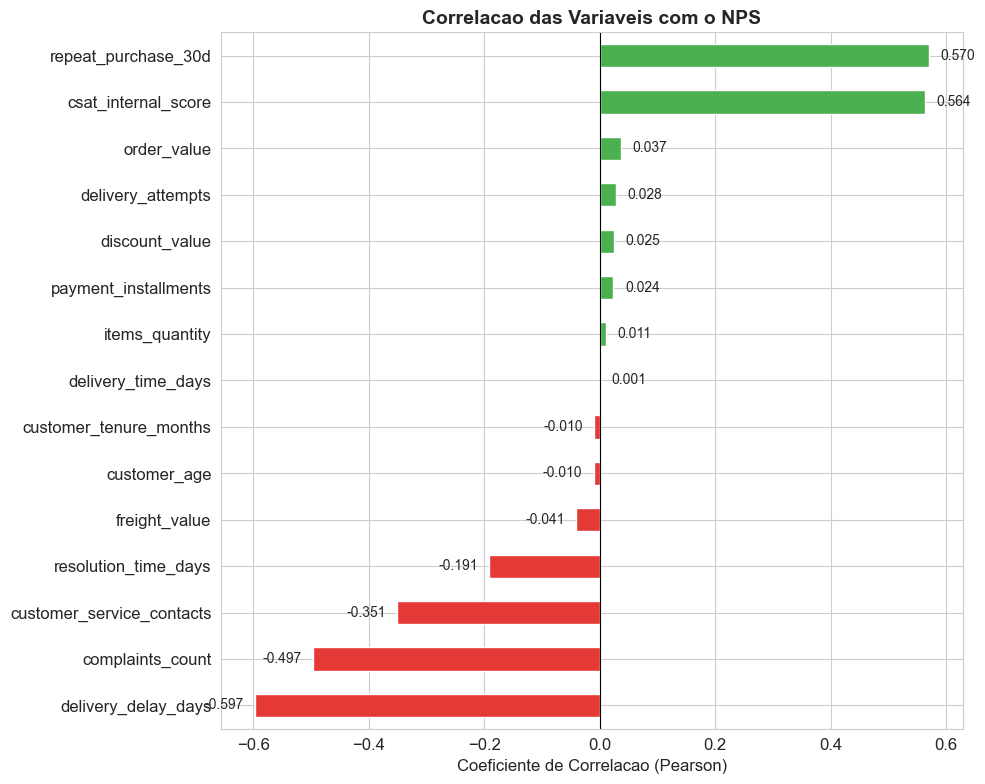

In [5]:
# ============================================================
# ANALISE DE CORRELACAO COM O NPS
# ============================================================

# Remove colunas de identificacao (IDs) e a propria variavel alvo do calculo
# Correlacao de Pearson: mede relacao linear entre -1 (inversa) e +1 (direta)
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop(['customer_id', 'order_id', 'nps_score'])
correlacoes = df[numeric_cols].corrwith(df['nps_score']).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))

# Barras vermelhas = correlacao negativa (prejudica o NPS)
# Barras verdes  = correlacao positiva (beneficia o NPS)
colors = ['#E53935' if v < 0 else '#4CAF50' for v in correlacoes.values]
correlacoes.plot(kind='barh', color=colors, ax=ax, edgecolor='white')
ax.set_title('Correlacao das Variaveis com o NPS', fontsize=14, fontweight='bold')
ax.set_xlabel('Coeficiente de Correlacao (Pearson)')
ax.axvline(x=0, color='black', linewidth=0.8)

# Adiciona os valores numericos ao lado de cada barra para facilitar leitura
for i, (val, name) in enumerate(zip(correlacoes.values, correlacoes.index)):
    ax.text(val + 0.02 if val >= 0 else val - 0.02, i, f'{val:.3f}',
            va='center', ha='left' if val >= 0 else 'right', fontsize=10)

plt.tight_layout()
plt.savefig('../reports/figures/02_correlacoes_nps.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight para o negócio:** Os três fatores que mais **prejudicam** a satisfação são:
1. **Atraso na entrega** (correlação -0.60) — é o maior vilão
2. **Quantidade de reclamações** (correlação -0.50)
3. **Contatos com atendimento** (correlação -0.35)

> ⚠️ **Atenção:** `repeat_purchase_30d` e `csat_internal_score` são consequências do NPS, não causas — não devem ser usadas como features no modelo (risco de data leakage).

### 3.4 O vilão número 1: Atraso na entrega

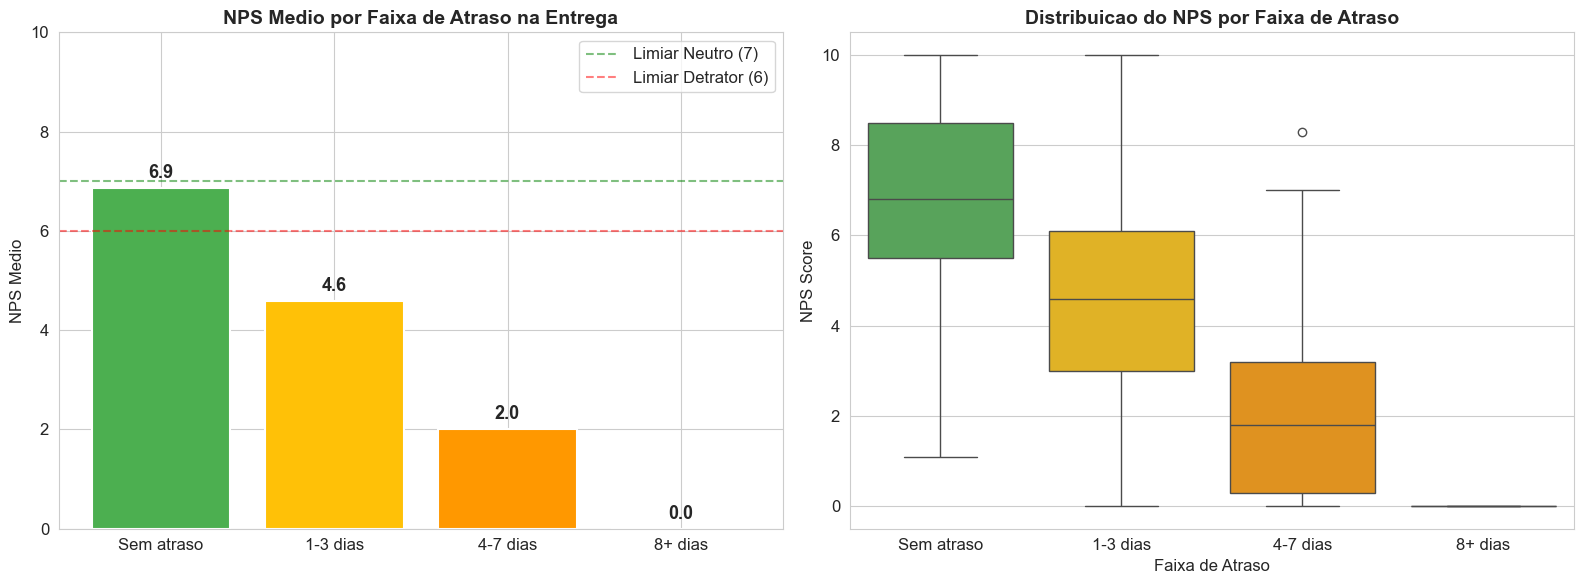

              mean  median  count
faixa_atraso                     
Sem atraso    6.86     6.8    277
1-3 dias      4.58     4.6   1786
4-7 dias      2.01     1.8    434
8+ dias       0.00     0.0      3

Clientes SEM atraso: NPS medio = 6.9
Com 4-7 dias de atraso, NPS despenca para 2.0

2223 pedidos (88.9%) tiveram algum atraso


In [6]:
# ============================================================
# ANALISE DO IMPACTO DO ATRASO NA ENTREGA
# ============================================================

# Agrupa os atrasos em faixas para facilitar a interpretacao gerencial
df['faixa_atraso'] = pd.cut(df['delivery_delay_days'],
                             bins=[-1, 0, 3, 7, 999],
                             labels=['Sem atraso', '1-3 dias', '4-7 dias', '8+ dias'])

# Agrega NPS medio, mediano e contagem por faixa de atraso
atraso_nps = df.groupby('faixa_atraso')['nps_score'].agg(['mean', 'median', 'count']).round(2)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Grafico 1: Barras com NPS medio por faixa ---
cores_atraso = ['#4CAF50', '#FFC107', '#FF9800', '#E53935']
bars = axes[0].bar(atraso_nps.index, atraso_nps['mean'], color=cores_atraso, edgecolor='white', linewidth=1.5)
axes[0].set_title('NPS Medio por Faixa de Atraso na Entrega', fontsize=14, fontweight='bold')
axes[0].set_ylabel('NPS Medio')
axes[0].set_ylim(0, 10)

# Linhas de referencia para facilitar a leitura dos limiares de satisfacao
axes[0].axhline(y=7, color='green', linestyle='--', alpha=0.5, label='Limiar Neutro (7)')
axes[0].axhline(y=6, color='red', linestyle='--', alpha=0.5, label='Limiar Detrator (6)')
axes[0].legend()
for bar, val in zip(bars, atraso_nps['mean']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f'{val:.1f}',
                ha='center', fontweight='bold', fontsize=13)

# --- Grafico 2: Boxplot para ver dispersao dentro de cada faixa ---
order = ['Sem atraso', '1-3 dias', '4-7 dias', '8+ dias']
sns.boxplot(data=df, x='faixa_atraso', y='nps_score', order=order, ax=axes[1], palette=cores_atraso)
axes[1].set_title('Distribuicao do NPS por Faixa de Atraso', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Faixa de Atraso')
axes[1].set_ylabel('NPS Score')

plt.tight_layout()
plt.savefig('../reports/figures/03_atraso_entrega.png', dpi=150, bbox_inches='tight')
plt.show()

print(atraso_nps)
print(f'\nClientes SEM atraso: NPS medio = {atraso_nps.loc["Sem atraso", "mean"]:.1f}')
print(f'Com 4-7 dias de atraso, NPS despenca para {atraso_nps.loc["4-7 dias", "mean"]:.1f}')
print(f'\n{(df["delivery_delay_days"] > 0).sum()} pedidos ({(df["delivery_delay_days"] > 0).mean()*100:.1f}%) tiveram algum atraso')

**Insight para o negócio:** Existe um claro **ponto de ruptura**:
- **Sem atraso:** NPS médio de 6.9 (quase neutro)
- **1-3 dias de atraso:** NPS cai para 4.6 (detrator)
- **4-7 dias:** NPS despenca para 2.0 (detrator severo)

**Qualquer atraso já prejudica significativamente a satisfação.**

### 3.5 O impacto das reclamações

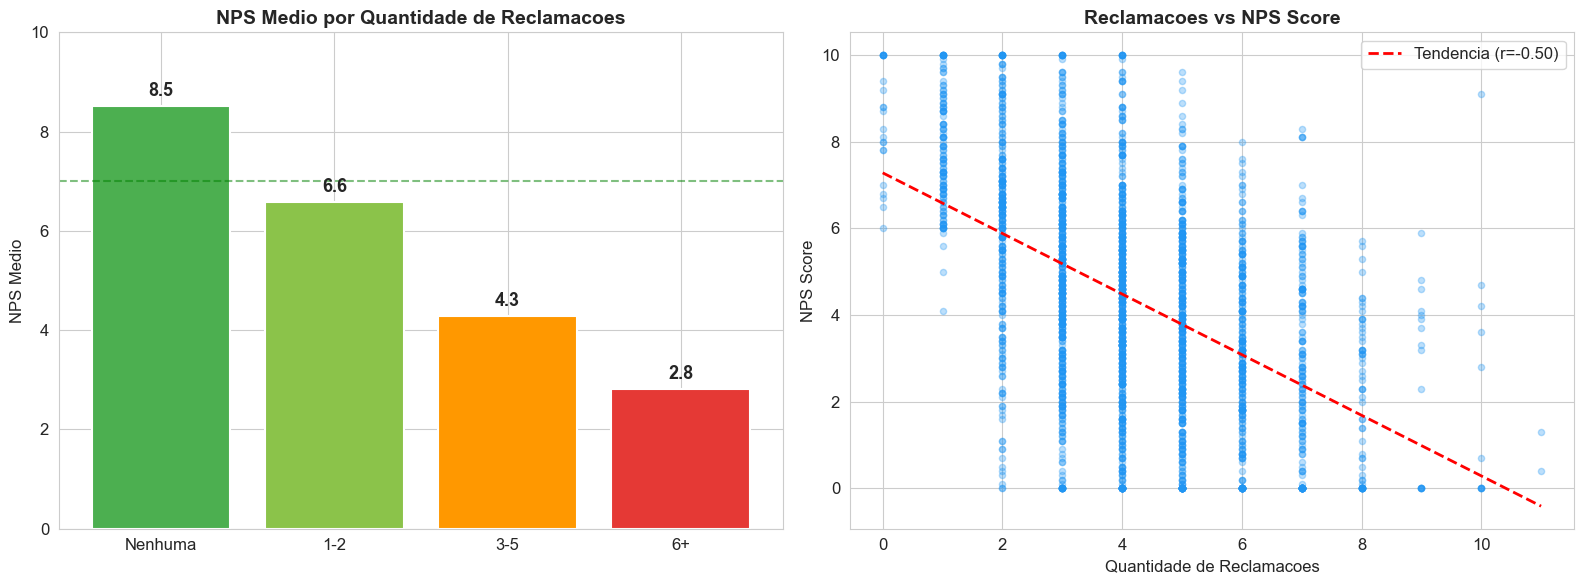

Media de reclamacoes: 4.2
Clientes com 0 reclamacoes: 23 (0.9%)


In [7]:
# ============================================================
# ANALISE DO IMPACTO DAS RECLAMACOES
# ============================================================

# Agrupa reclamacoes em faixas para analise segmentada
df['faixa_reclamacoes'] = pd.cut(df['complaints_count'],
                                   bins=[-1, 0, 2, 5, 999],
                                   labels=['Nenhuma', '1-2', '3-5', '6+'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Grafico 1: NPS medio por faixa de reclamacoes ---
rec_nps = df.groupby('faixa_reclamacoes')['nps_score'].mean()
cores_rec = ['#4CAF50', '#8BC34A', '#FF9800', '#E53935']
bars = axes[0].bar(rec_nps.index, rec_nps.values, color=cores_rec, edgecolor='white', linewidth=1.5)
axes[0].set_title('NPS Medio por Quantidade de Reclamacoes', fontsize=14, fontweight='bold')
axes[0].set_ylabel('NPS Medio')
axes[0].set_ylim(0, 10)
axes[0].axhline(y=7, color='green', linestyle='--', alpha=0.5)
for bar, val in zip(bars, rec_nps.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f'{val:.1f}',
                ha='center', fontweight='bold', fontsize=13)

# --- Grafico 2: Scatter com linha de tendencia (regressao linear simples) ---
axes[1].scatter(df['complaints_count'], df['nps_score'], alpha=0.3, color='#2196F3', s=20)
# np.polyfit calcula os coeficientes da linha de tendencia linear
z = np.polyfit(df['complaints_count'], df['nps_score'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['complaints_count'].min(), df['complaints_count'].max(), 100)
axes[1].plot(x_line, p(x_line), 'r--', linewidth=2,
             label=f'Tendencia (r={correlacoes["complaints_count"]:.2f})')
axes[1].set_title('Reclamacoes vs NPS Score', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Quantidade de Reclamacoes')
axes[1].set_ylabel('NPS Score')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/04_reclamacoes.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Media de reclamacoes: {df["complaints_count"].mean():.1f}')
print(f'Clientes com 0 reclamacoes: {(df["complaints_count"] == 0).sum()} ({(df["complaints_count"] == 0).mean()*100:.1f}%)')

**Insight para o negócio:** Clientes sem reclamação têm NPS de 8.5 (promotores!). Com 3-5 reclamações, o NPS cai para 4.3. A média de 4+ reclamações por cliente indica problemas sistemáticos na operação.

### 3.6 Contatos com atendimento — mais contato = menos satisfação

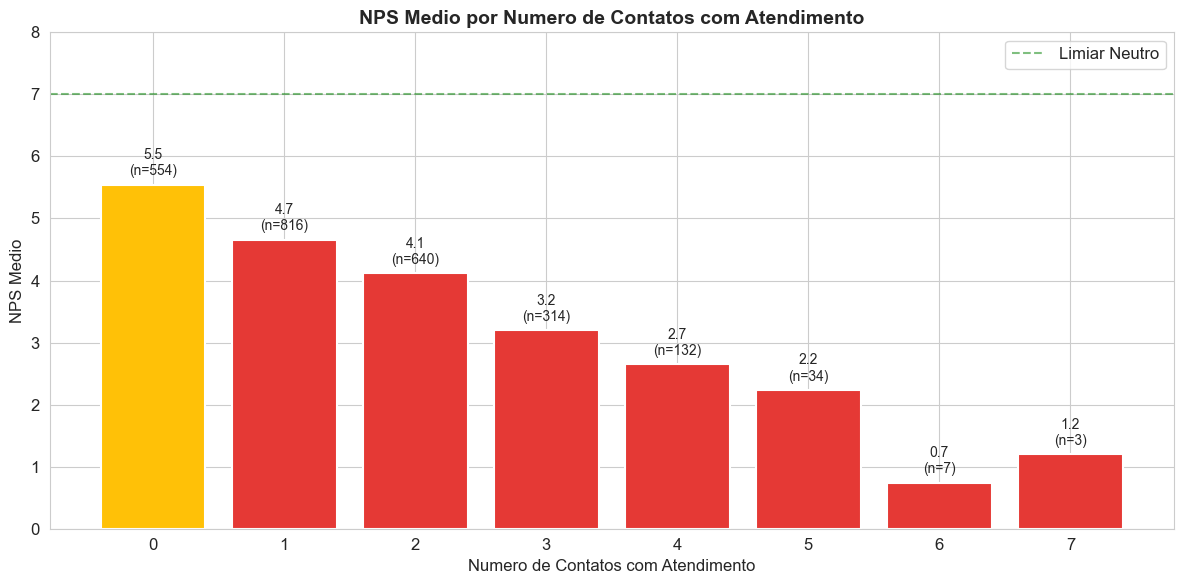

In [8]:
# ============================================================
# ANALISE DE CONTATOS COM O ATENDIMENTO
# ============================================================

# Agrupa por numero de contatos e calcula NPS medio e contagem
contatos_nps = df.groupby('customer_service_contacts')['nps_score'].agg(['mean', 'count'])

fig, ax = plt.subplots(figsize=(12, 6))

# Cor indica qualidade: verde = NPS alto, amarelo = medio, vermelho = baixo
bar_colors = ['#4CAF50' if v >= 7 else '#FFC107' if v >= 5 else '#E53935' for v in contatos_nps['mean']]
bars = ax.bar(contatos_nps.index, contatos_nps['mean'], color=bar_colors, edgecolor='white', linewidth=1.5)
ax.set_title('NPS Medio por Numero de Contatos com Atendimento', fontsize=14, fontweight='bold')
ax.set_xlabel('Numero de Contatos com Atendimento')
ax.set_ylabel('NPS Medio')
ax.set_ylim(0, 8)
ax.axhline(y=7, color='green', linestyle='--', alpha=0.5, label='Limiar Neutro')

# Exibe NPS medio e quantidade de clientes em cada barra
for bar, val, n in zip(bars, contatos_nps['mean'], contatos_nps['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15, f'{val:.1f}\n(n={n})',
            ha='center', fontsize=10)

ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/05_contatos_atendimento.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight para o negócio:** Quanto mais vezes o cliente precisa contatar o SAC, pior a satisfação. Isso indica que o atendimento não está resolvendo problemas de forma eficiente no primeiro contato.

### 3.7 Perfil do cliente — Existe diferença por região, idade ou tempo de relacionamento?

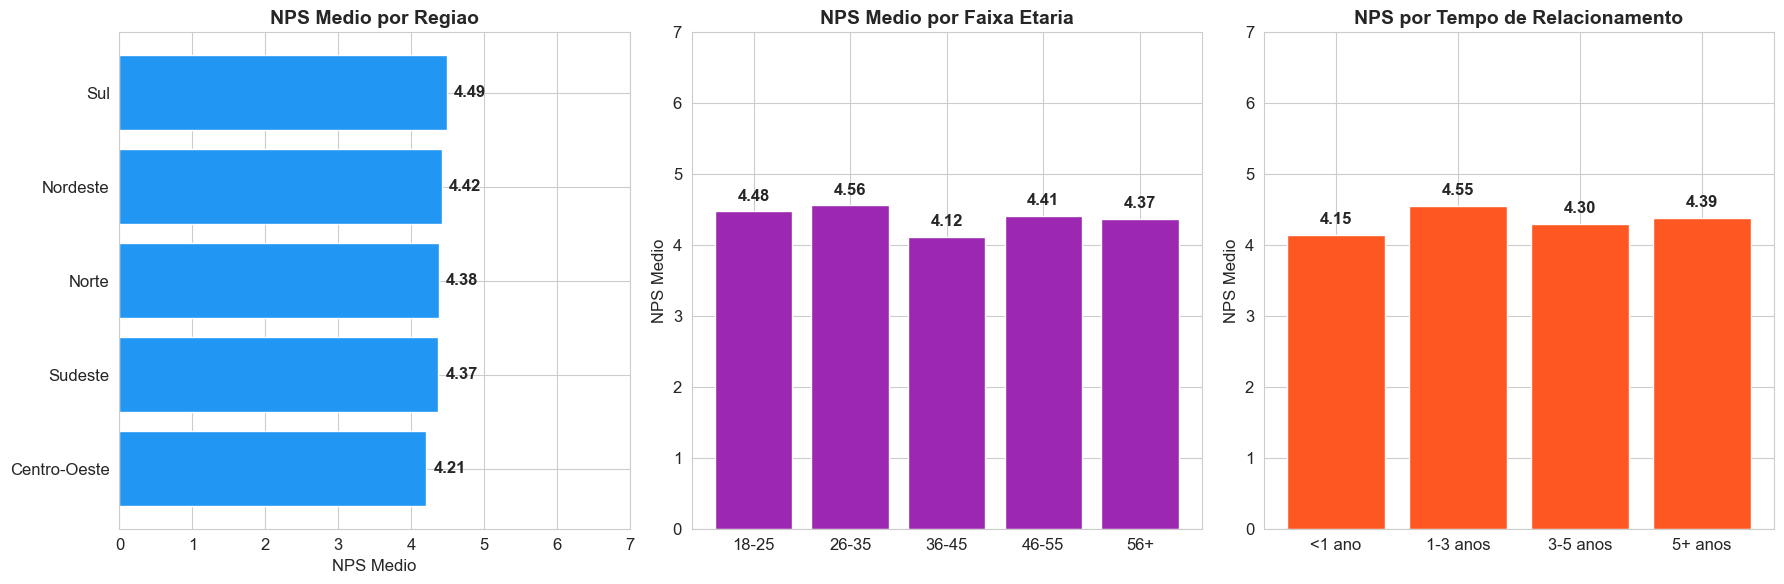

In [9]:
# ============================================================
# ANALISE DO PERFIL DEMOGRAFICO DOS CLIENTES
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- NPS por regiao ---
region_nps = df.groupby('customer_region')['nps_score'].mean().sort_values()
axes[0].barh(region_nps.index, region_nps.values, color='#2196F3', edgecolor='white')
axes[0].set_title('NPS Medio por Regiao', fontsize=14, fontweight='bold')
axes[0].set_xlabel('NPS Medio')
axes[0].set_xlim(0, 7)
for i, val in enumerate(region_nps.values):
    axes[0].text(val + 0.1, i, f'{val:.2f}', va='center', fontweight='bold')

# --- NPS por faixa etaria ---
df['faixa_etaria'] = pd.cut(df['customer_age'],
                             bins=[17, 25, 35, 45, 55, 70],
                             labels=['18-25', '26-35', '36-45', '46-55', '56+'])
idade_nps = df.groupby('faixa_etaria')['nps_score'].mean()
axes[1].bar(idade_nps.index, idade_nps.values, color='#9C27B0', edgecolor='white')
axes[1].set_title('NPS Medio por Faixa Etaria', fontsize=14, fontweight='bold')
axes[1].set_ylabel('NPS Medio')
axes[1].set_ylim(0, 7)
for i, val in enumerate(idade_nps.values):
    axes[1].text(i, val + 0.15, f'{val:.2f}', ha='center', fontweight='bold')

# --- NPS por tempo de relacionamento ---
df['faixa_tenure'] = pd.cut(df['customer_tenure_months'],
                              bins=[0, 12, 36, 60, 200],
                              labels=['<1 ano', '1-3 anos', '3-5 anos', '5+ anos'])
tenure_nps = df.groupby('faixa_tenure')['nps_score'].mean()
axes[2].bar(tenure_nps.index, tenure_nps.values, color='#FF5722', edgecolor='white')
axes[2].set_title('NPS por Tempo de Relacionamento', fontsize=14, fontweight='bold')
axes[2].set_ylabel('NPS Medio')
axes[2].set_ylim(0, 7)
for i, val in enumerate(tenure_nps.values):
    axes[2].text(i, val + 0.15, f'{val:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/06_perfil_cliente.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight para o negócio:** Região, idade e tempo de relacionamento **não são fatores determinantes** do NPS — as diferenças são mínimas. A insatisfação é causada por **fatores operacionais**, não pelo perfil demográfico. As ações de melhoria podem ser universais.

### 3.8 Mapa de calor — correlações entre variáveis

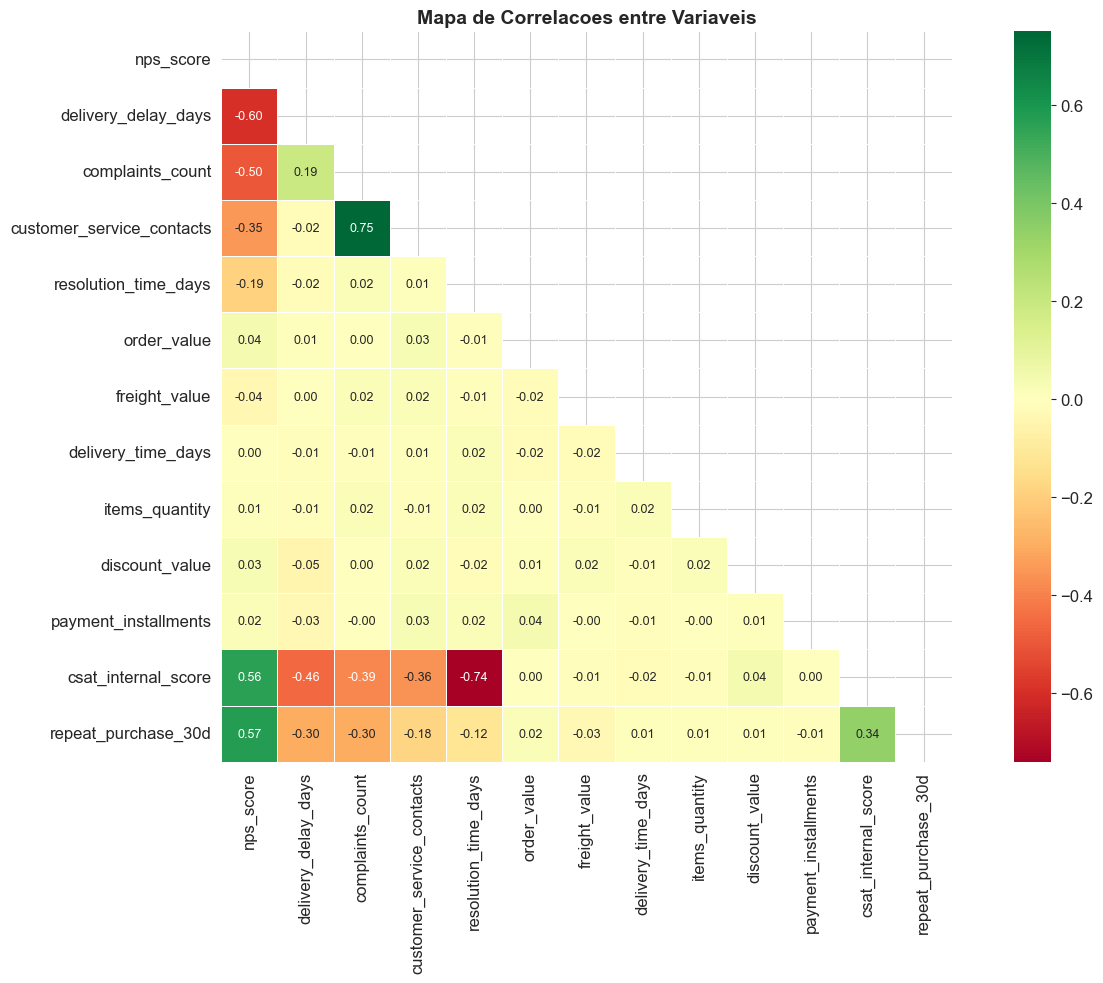

In [10]:
# ============================================================
# MAPA DE CALOR DE CORRELACOES ENTRE VARIAVEIS
# ============================================================

# Seleciona variaveis relevantes para a analise de correlacao cruzada
cols_analise = ['nps_score', 'delivery_delay_days', 'complaints_count',
                'customer_service_contacts', 'resolution_time_days',
                'order_value', 'freight_value', 'delivery_time_days',
                'items_quantity', 'discount_value', 'payment_installments',
                'csat_internal_score', 'repeat_purchase_30d']

fig, ax = plt.subplots(figsize=(14, 10))

# Mascara triangular: exibe apenas metade inferior para evitar duplicacao
mask = np.triu(np.ones_like(df[cols_analise].corr(), dtype=bool))

# Paleta RdYlGn: vermelho (negativo) -> amarelo (neutro) -> verde (positivo)
# center=0 faz o ponto neutro corresponder ao amarelo
sns.heatmap(df[cols_analise].corr().round(2), annot=True, cmap='RdYlGn', center=0,
            mask=mask, square=True, linewidths=0.5, ax=ax, fmt='.2f',
            annot_kws={'size': 9})
ax.set_title('Mapa de Correlacoes entre Variaveis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/07_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.9 Resumo da EDA — Resposta às perguntas de negócio

| Pergunta | Resposta |
|----------|----------|
| **Quais fatores parecem mais críticos para a satisfação?** | Atraso na entrega (-0.60), reclamações (-0.50) e contatos com atendimento (-0.35) |
| **O que mais gera detratores?** | Atrasos acima de 1 dia já transformam clientes em detratores. Com 4+ dias, NPS despenca para 2.0 |
| **Existe um ponto de ruptura?** | Sim — o primeiro dia de atraso já causa queda significativa (de 6.9 para 4.6) |
| **Que tipo de cliente tem NPS mais alto/baixo?** | Não é questão de perfil (região/idade), mas de experiência operacional |

# 4 - Reflexão sobre Modelo Preditivo (Requisito 4)

## 4.1 Preparação dos dados

Variáveis excluídas por risco de data leakage: `csat_internal_score` e `repeat_purchase_30d` — são consequências da satisfação, não causas. Usá-las seria como usar a resposta para adivinhar a pergunta.

In [11]:
# ============================================================
# PREPARAÇÃO DOS DADOS PARA MODELAGEM
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               RandomForestRegressor, GradientBoostingRegressor)
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                              roc_curve, ConfusionMatrixDisplay,
                              mean_absolute_error, mean_squared_error, r2_score)
from sklearn.inspection import permutation_importance

# Variável alvo — classificação binária
df['satisfeito'] = (df['nps_score'] >= 7).astype(int)
print(f'Distribuição da target:')
print(f'  Insatisfeito (0): {(df["satisfeito"]==0).sum()} ({(df["satisfeito"]==0).mean()*100:.1f}%)')
print(f'  Satisfeito (1):   {(df["satisfeito"]==1).sum()} ({(df["satisfeito"]==1).mean()*100:.1f}%)')
print(f'\n⚠️  Base desbalanceada — acurácia sozinha NÃO é boa métrica')

# Features operacionais (sem leakage)
features = [
    'customer_age', 'customer_tenure_months',
    'order_value', 'items_quantity', 'discount_value', 'payment_installments',
    'delivery_time_days', 'delivery_delay_days', 'freight_value', 'delivery_attempts',
    'customer_service_contacts', 'resolution_time_days', 'complaints_count'
]

le = LabelEncoder()
df['region_encoded'] = le.fit_transform(df['customer_region'])
features.append('region_encoded')

X = df[features]
y_class = df['satisfeito']
y_reg = df['nps_score']

# Separação treino/teste
X_train, X_test, y_train_class, y_test_class = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)
_, _, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42, stratify=y_class
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'\nTreino: {X_train.shape[0]} registros | Teste: {X_test.shape[0]} registros')
print(f'Features: {len(features)}')
print(f'Excluídas por leakage: csat_internal_score, repeat_purchase_30d')

Distribuição da target:
  Insatisfeito (0): 2109 (84.4%)
  Satisfeito (1):   391 (15.6%)

⚠️  Base desbalanceada — acurácia sozinha NÃO é boa métrica

Treino: 2000 registros | Teste: 500 registros
Features: 14
Excluídas por leakage: csat_internal_score, repeat_purchase_30d


## 4.2 Modelos de Classificação — Análise Crítica

Treinamos três modelos para comparar. Mas atenção: **acurácia e AUC não contam a história completa**. Com uma base desbalanceada (84% insatisfeitos), um modelo que chuta "insatisfeito" pra todo mundo já acerta 84%. O que importa é: **o modelo consegue identificar bem as DUAS classes?**

In [12]:
# ============================================================
# MODELOS DE CLASSIFICAÇÃO — ANÁLISE CRÍTICA
# ============================================================

modelos = {
    'Regressão Logística': LogisticRegression(max_iter=5000, random_state=42, class_weight='balanced'),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced'),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, random_state=42)
}

resultados = {}

for nome, modelo in modelos.items():
    if nome == 'Regressão Logística':
        modelo.fit(X_train_scaled, y_train_class)
        y_pred  = modelo.predict(X_test_scaled)
        y_proba = modelo.predict_proba(X_test_scaled)[:, 1]
    else:
        modelo.fit(X_train, y_train_class)
        y_pred  = modelo.predict(X_test)
        y_proba = modelo.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test_class, y_proba)
    resultados[nome] = {'modelo': modelo, 'y_pred': y_pred, 'y_proba': y_proba, 'auc': auc}

    print(f'\n{"="*60}')
    print(f'  {nome} — AUC-ROC: {auc:.4f}')
    print(f'{"="*60}')
    print(classification_report(y_test_class, y_pred, target_names=['Insatisfeito', 'Satisfeito']))

# Resumo comparativo
print('\n' + '='*60)
print('  RESUMO COMPARATIVO')
print('='*60)
for nome, res in resultados.items():
    print(f'  {nome}: AUC-ROC = {res["auc"]:.4f}')


  Regressão Logística — AUC-ROC: 0.8640
              precision    recall  f1-score   support

Insatisfeito       0.94      0.80      0.87       422
  Satisfeito       0.41      0.74      0.52        78

    accuracy                           0.79       500
   macro avg       0.67      0.77      0.70       500
weighted avg       0.86      0.79      0.81       500




  Random Forest — AUC-ROC: 0.8771
              precision    recall  f1-score   support

Insatisfeito       0.88      0.99      0.93       422
  Satisfeito       0.77      0.26      0.38        78

    accuracy                           0.87       500
   macro avg       0.82      0.62      0.66       500
weighted avg       0.86      0.87      0.84       500




  Gradient Boosting — AUC-ROC: 0.8630
              precision    recall  f1-score   support

Insatisfeito       0.89      0.96      0.92       422
  Satisfeito       0.62      0.37      0.46        78

    accuracy                           0.87       500
   macro avg       0.75      0.66      0.69       500
weighted avg       0.85      0.87      0.85       500


  RESUMO COMPARATIVO
  Regressão Logística: AUC-ROC = 0.8640
  Random Forest: AUC-ROC = 0.8771
  Gradient Boosting: AUC-ROC = 0.8630


### Análise Crítica — Por que NÃO escolher só pela acurácia

O **Random Forest** teve a maior acurácia (87%) e AUC (0.877), mas tem um problema grave: **recall de apenas 0.26 para a classe "Satisfeito"**. Isso significa que de todos os clientes realmente satisfeitos, ele só identifica 26%. Ele parece bom porque acerta muito a classe majoritária (Insatisfeito), mas falha na minoritária.

A **Regressão Logística** teve acurácia menor (79%), mas é **muito mais equilibrada**: recall de 0.80 para Insatisfeito e 0.74 para Satisfeito. Ela identifica bem as duas classes.

**Para este problema, a Regressão Logística é a melhor escolha porque:**
- O objetivo é **analisar e entender** os fatores de insatisfação, não só classificar
- Equilíbrio entre as classes é mais importante que acurácia bruta
- É o modelo mais interpretável — os coeficientes indicam diretamente o peso de cada fator
- Em uma base desbalanceada, acurácia alta pode ser ilusória

Usaremos a Regressão Logística como modelo principal nas análises seguintes.

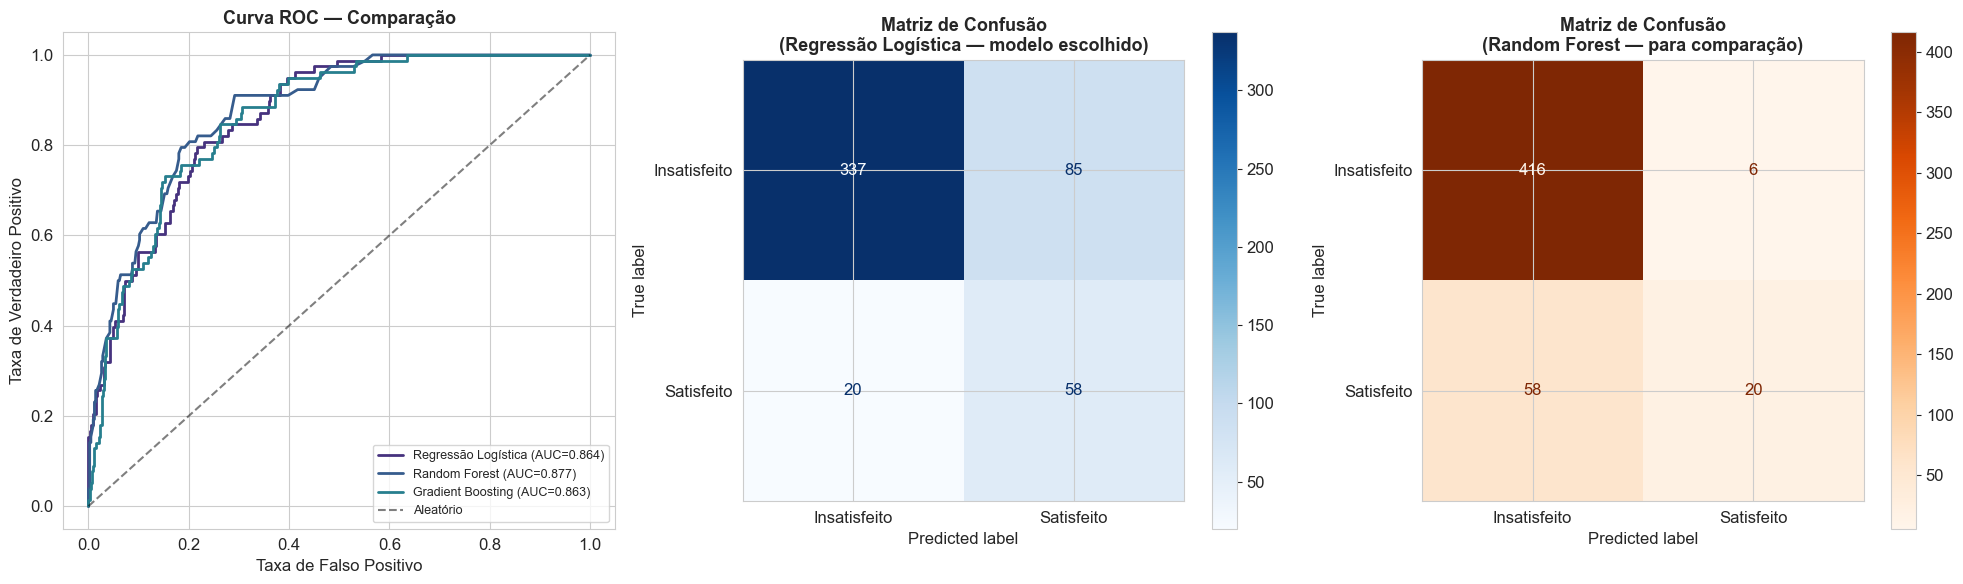

A Regressão Logística erra mais no geral, mas erra de forma equilibrada.
O Random Forest acerta quase tudo como Insatisfeito, mas perde a maioria dos Satisfeitos.


In [13]:
# ============================================================
# VISUALIZAÇÃO — CURVA ROC E MATRIZ DE CONFUSÃO
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Curvas ROC
ax = axes[0]
for nome, res in resultados.items():
    fpr, tpr, _ = roc_curve(y_test_class, res['y_proba'])
    ax.plot(fpr, tpr, linewidth=2, label=f"{nome} (AUC={res['auc']:.3f})")
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Aleatório')
ax.set_title('Curva ROC — Comparação', fontsize=13, fontweight='bold')
ax.set_xlabel('Taxa de Falso Positivo')
ax.set_ylabel('Taxa de Verdadeiro Positivo')
ax.legend(fontsize=9)

# 2. Matriz de confusão — Regressão Logística (modelo escolhido)
ax = axes[1]
ConfusionMatrixDisplay.from_predictions(
    y_test_class, resultados['Regressão Logística']['y_pred'],
    display_labels=['Insatisfeito', 'Satisfeito'],
    cmap='Blues', ax=ax
)
ax.set_title('Matriz de Confusão\n(Regressão Logística — modelo escolhido)', fontsize=13, fontweight='bold')

# 3. Matriz de confusão — Random Forest (para comparação)
ax = axes[2]
ConfusionMatrixDisplay.from_predictions(
    y_test_class, resultados['Random Forest']['y_pred'],
    display_labels=['Insatisfeito', 'Satisfeito'],
    cmap='Oranges', ax=ax
)
ax.set_title('Matriz de Confusão\n(Random Forest — para comparação)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/modelos_classificacao.png', dpi=150, bbox_inches='tight')
plt.show()

print('A Regressão Logística erra mais no geral, mas erra de forma equilibrada.')
print('O Random Forest acerta quase tudo como Insatisfeito, mas perde a maioria dos Satisfeitos.')

## 4.3 Modelo de Regressão — Estimando a nota contínua do NPS

Além da classificação (satisfeito/insatisfeito), podemos tentar **estimar a nota exata do NPS** (0 a 10). Isso dá mais granularidade — em vez de só "vai ser detrator ou não", conseguimos dizer "esse cliente provavelmente daria nota 3.2".


  Regressão Linear
  MAE  (erro médio): 1.39 pontos
  RMSE (erro quadrático): 1.77 pontos
  R²   (explicação): 0.5136 (51.4% da variação explicada)



  Random Forest Reg
  MAE  (erro médio): 1.39 pontos
  RMSE (erro quadrático): 1.78 pontos
  R²   (explicação): 0.5068 (50.7% da variação explicada)



  Gradient Boosting Reg
  MAE  (erro médio): 1.40 pontos
  RMSE (erro quadrático): 1.78 pontos
  R²   (explicação): 0.5055 (50.5% da variação explicada)

🏆 Melhor modelo de regressão: Regressão Linear (MAE: 1.39)


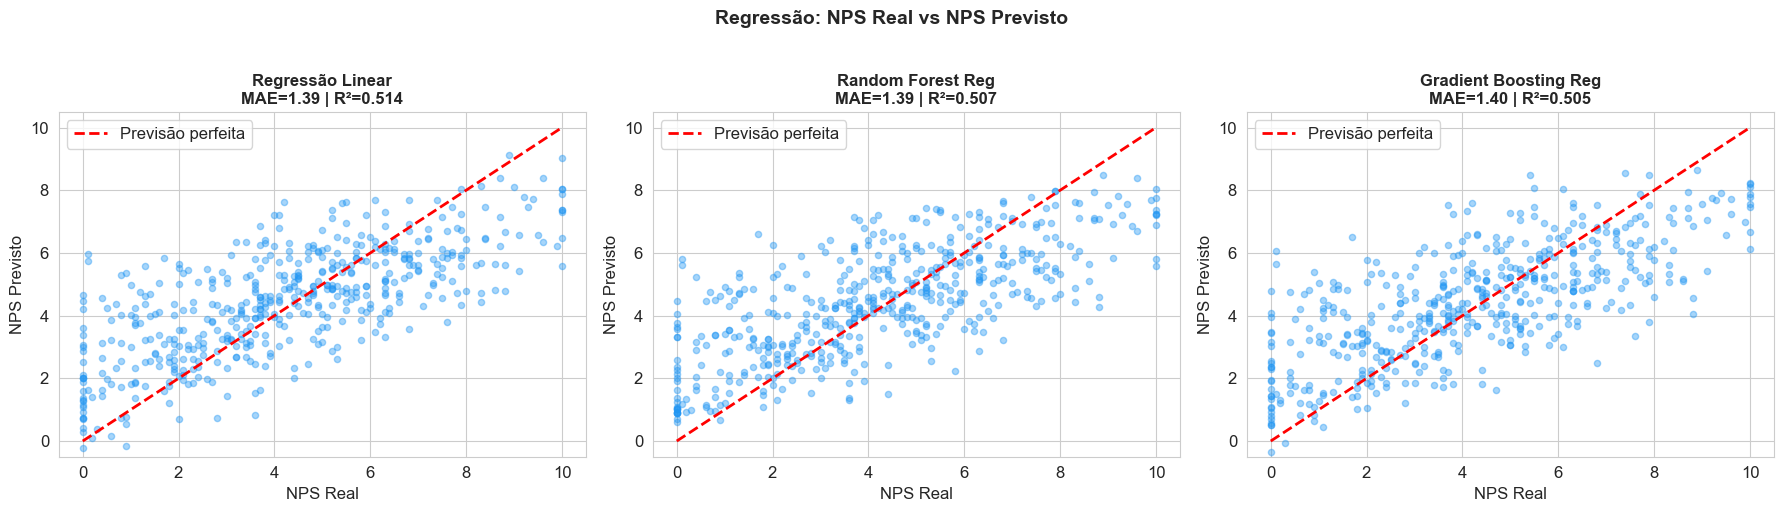

In [14]:
# ============================================================
# MODELOS DE REGRESSÃO — ESTIMAR NOTA CONTÍNUA DO NPS
# ============================================================

modelos_reg = {
    'Regressão Linear':      LinearRegression(),
    'Random Forest Reg':     RandomForestRegressor(n_estimators=200, random_state=42),
    'Gradient Boosting Reg': GradientBoostingRegressor(n_estimators=200, random_state=42)
}

resultados_reg = {}

for nome, modelo in modelos_reg.items():
    if nome == 'Regressão Linear':
        modelo.fit(X_train_scaled, y_train_reg)
        y_pred = modelo.predict(X_test_scaled)
    else:
        modelo.fit(X_train, y_train_reg)
        y_pred = modelo.predict(X_test)

    mae  = mean_absolute_error(y_test_reg, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred))
    r2   = r2_score(y_test_reg, y_pred)
    resultados_reg[nome] = {'modelo': modelo, 'y_pred': y_pred, 'mae': mae, 'rmse': rmse, 'r2': r2}

    print(f'\n{"="*60}')
    print(f'  {nome}')
    print(f'{"="*60}')
    print(f'  MAE  (erro médio): {mae:.2f} pontos')
    print(f'  RMSE (erro quadrático): {rmse:.2f} pontos')
    print(f'  R²   (explicação): {r2:.4f} ({r2*100:.1f}% da variação explicada)')

# Melhor modelo de regressão (menor MAE)
melhor_reg = min(resultados_reg, key=lambda k: resultados_reg[k]['mae'])
print(f'\n🏆 Melhor modelo de regressão: {melhor_reg} (MAE: {resultados_reg[melhor_reg]["mae"]:.2f})')

# Gráfico: Real vs Previsto
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (nome, res) in zip(axes, resultados_reg.items()):
    ax.scatter(y_test_reg, res['y_pred'], alpha=0.4, s=20, color='#2196F3')
    ax.plot([0, 10], [0, 10], 'r--', lw=2, label='Previsão perfeita')
    ax.set_title(f'{nome}\nMAE={res["mae"]:.2f} | R²={res["r2"]:.3f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('NPS Real')
    ax.set_ylabel('NPS Previsto')
    ax.set_xlim(-0.5, 10.5)
    ax.set_ylim(-0.5, 10.5)
    ax.legend()

plt.suptitle('Regressão: NPS Real vs NPS Previsto', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/modelos_regressao.png', dpi=150, bbox_inches='tight')
plt.show()

### Classificação vs Regressão — Qual faz mais sentido?

Ambas as abordagens trazem valor:

| Abordagem | Vantagem | Quando usar |
| :--- | :--- | :--- |
| **Classificação** (satisfeito/insatisfeito) | Simples e acionável — gera alertas diretos | Quando o objetivo é **agir** (ligar, enviar cupom) |
| **Regressão** (nota contínua) | Mais granular — mostra intensidade | Quando o objetivo é **analisar** e priorizar |

Para este caso, as **duas se complementam**: a regressão estima a nota e a classificação gera a ação. Nos CSVs de aplicação prática, usaremos ambas.

## 4.4 Feature Importance — Quais fatores mais influenciam a insatisfação?

Mais importante que "o modelo acertou X%" é entender **por que** ele classifica um cliente como insatisfeito. Isso transforma o modelo de uma "caixa preta" em uma ferramenta de diagnóstico.

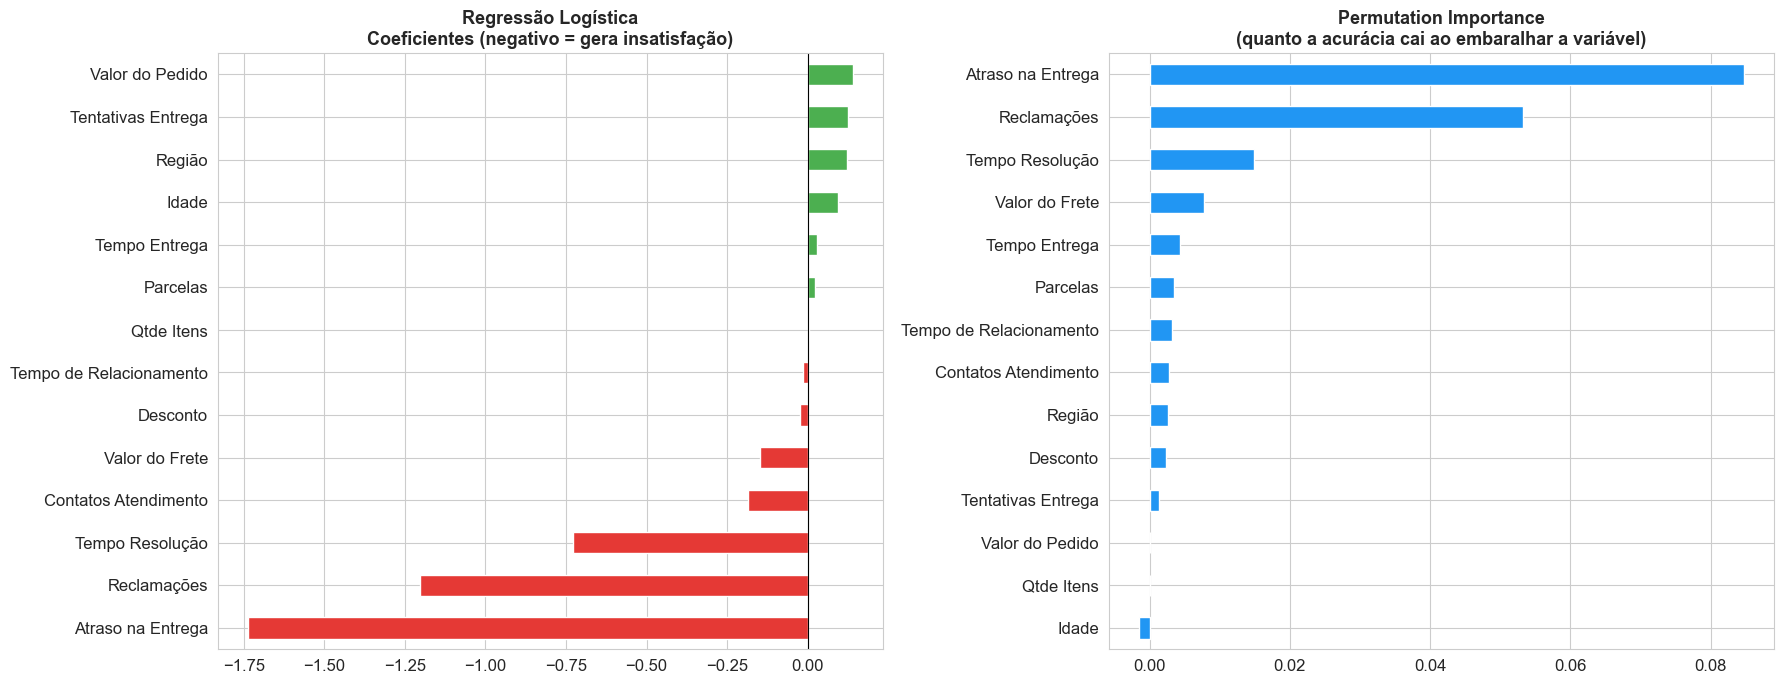


📊 TOP 5 fatores que mais influenciam a insatisfação:
  1. Atraso na Entrega (coeficiente: -1.737)
  2. Reclamações (coeficiente: -1.204)
  3. Tempo Resolução (coeficiente: -0.729)
  4. Contatos Atendimento (coeficiente: -0.185)
  5. Valor do Frete (coeficiente: -0.146)


In [15]:
# ============================================================
# FEATURE IMPORTANCE — QUAIS FATORES MAIS INFLUENCIAM
# ============================================================

# Nomes legíveis para os gráficos
nomes_legiveis = {
    'customer_age': 'Idade',
    'customer_tenure_months': 'Tempo de Relacionamento',
    'order_value': 'Valor do Pedido',
    'items_quantity': 'Qtde Itens',
    'discount_value': 'Desconto',
    'payment_installments': 'Parcelas',
    'delivery_time_days': 'Tempo Entrega',
    'delivery_delay_days': 'Atraso na Entrega',
    'freight_value': 'Valor do Frete',
    'delivery_attempts': 'Tentativas Entrega',
    'customer_service_contacts': 'Contatos Atendimento',
    'resolution_time_days': 'Tempo Resolução',
    'complaints_count': 'Reclamações',
    'region_encoded': 'Região'
}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. Coeficientes da Regressão Logística (interpretação direta)
coefs = pd.Series(
    resultados['Regressão Logística']['modelo'].coef_[0],
    index=[nomes_legiveis[f] for f in features]
).sort_values()

colors = ['#E53935' if v < 0 else '#4CAF50' for v in coefs.values]
coefs.plot(kind='barh', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Regressão Logística\nCoeficientes (negativo = gera insatisfação)', fontsize=13, fontweight='bold')
axes[0].axvline(x=0, color='black', lw=0.8)

# 2. Permutation Importance (mais robusto — valida os coeficientes)
modelo_log = resultados['Regressão Logística']['modelo']
perm_imp = permutation_importance(modelo_log, X_test_scaled, y_test_class, n_repeats=30, random_state=42)
perm_series = pd.Series(
    perm_imp.importances_mean,
    index=[nomes_legiveis[f] for f in features]
).sort_values(ascending=True)

perm_series.plot(kind='barh', ax=axes[1], color='#2196F3', edgecolor='white')
axes[1].set_title('Permutation Importance\n(quanto a acurácia cai ao embaralhar a variável)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Top 5 fatores negativos (maiores geradores de insatisfação)
print('\n📊 TOP 5 fatores que mais influenciam a insatisfação:')
top5 = coefs.head(5)
for i, (nome, val) in enumerate(top5.items(), 1):
    print(f'  {i}. {nome} (coeficiente: {val:.3f})')

**Interpretação para o negócio:**

Os coeficientes da Regressão Logística mostram diretamente o impacto de cada fator. Valores negativos **aumentam** a chance de insatisfação. Os fatores com maior impacto são consistentes com a EDA:

1. **Atraso na entrega** — maior destruidor de satisfação
2. **Reclamações** — cada reclamação adicional piora significativamente
3. **Contatos com atendimento** — indica problemas não resolvidos

Fatores como idade, região e valor do pedido têm impacto desprezível, confirmando que **a insatisfação é operacional, não demográfica**.

## 4.5 Aplicação Prática — CSVs de simulação

Aqui transformamos o modelo em ferramenta de trabalho. Geramos dois arquivos que simulam como a empresa usaria o modelo no dia a dia.

In [16]:
# ============================================================
# CSV 1 — EXEMPLOS DE PREDIÇÃO (conjunto de teste)
# ============================================================

modelo_escolhido    = resultados['Regressão Logística']['modelo']
y_proba_log         = resultados['Regressão Logística']['y_proba']
y_pred_log          = resultados['Regressão Logística']['y_pred']

# Nota contínua prevista pelo melhor modelo de regressão
modelo_reg_escolhido = resultados_reg[melhor_reg]['modelo']
if melhor_reg == 'Regressão Linear':
    nps_previsto = modelo_reg_escolhido.predict(X_test_scaled)
else:
    nps_previsto = modelo_reg_escolhido.predict(X_test)

df_predicoes = pd.DataFrame({
    'customer_id':      df.loc[X_test.index, 'customer_id'].values,
    'nps_real':         y_test_reg.values,
    'nps_previsto':     np.round(nps_previsto, 1),
    'classe_real':      ['Satisfeito' if v == 1 else 'Insatisfeito' for v in y_test_class.values],
    'classe_prevista':  ['Satisfeito' if v == 1 else 'Insatisfeito' for v in y_pred_log],
    'prob_insatisfeito': np.round(1 - y_proba_log, 3),
    'prob_satisfeito':  np.round(y_proba_log, 3),
    'acerto':           ['Acertou' if r == p else 'Errou' for r, p in zip(y_test_class.values, y_pred_log)]
})

df_predicoes = df_predicoes.sort_values('prob_insatisfeito', ascending=False)
df_predicoes.to_csv('../models/predicoes_nps.csv', index=False, encoding='utf-8-sig')

print(f'Arquivo gerado: predicoes_nps.csv ({len(df_predicoes)} registros)')
print(f'Acertos: {(df_predicoes["acerto"] == "Acertou").sum()} ({(df_predicoes["acerto"] == "Acertou").mean()*100:.1f}%)')
print(f'\nPrimeiras 10 linhas (ordenadas por maior risco):')
df_predicoes.head(10)

Arquivo gerado: predicoes_nps.csv (500 registros)
Acertos: 395 (79.0%)

Primeiras 10 linhas (ordenadas por maior risco):


,customer_id,nps_real,nps_previsto,classe_real,classe_prevista,prob_insatisfeito,prob_satisfeito,acerto
138,2138,0.9,-0.2,Insatisfeito,Insatisfeito,1.000,0.000,Acertou
88,462,0.0,-1.7,Insatisfeito,Insatisfeito,1.000,0.000,Acertou
288,2035,0.2,0.1,Insatisfeito,Insatisfeito,0.999,0.001,Acertou
217,1932,0.3,0.4,Insatisfeito,Insatisfeito,0.999,0.001,Acertou
272,2244,0.8,0.7,Insatisfeito,Insatisfeito,0.999,0.001,Acertou
126,2051,0.0,-0.2,Insatisfeito,Insatisfeito,0.999,0.001,Acertou
53,169,3.6,0.8,Insatisfeito,Insatisfeito,0.999,0.001,Acertou
446,407,0.9,0.8,Insatisfeito,Insatisfeito,0.998,0.002,Acertou
357,1143,0.0,0.4,Insatisfeito,Insatisfeito,0.998,0.002,Acertou
17,751,0.9,0.5,Insatisfeito,Insatisfeito,0.998,0.002,Acertou


In [17]:
# ============================================================
# CSV 2 — SIMULAÇÃO DE APLICAÇÃO PRÁTICA (toda a base)
# ============================================================

X_all_scaled = scaler.transform(df[features])
prob_satisfeito_all   = modelo_escolhido.predict_proba(X_all_scaled)[:, 1]
prob_insatisfeito_all = 1 - prob_satisfeito_all

if melhor_reg == 'Regressão Linear':
    nps_previsto_all = modelo_reg_escolhido.predict(X_all_scaled)
else:
    nps_previsto_all = modelo_reg_escolhido.predict(df[features])

nps_previsto_all = np.clip(nps_previsto_all, 0, 10)

def definir_prioridade(prob_insat):
    if prob_insat >= 0.80:
        return 'ALTA'
    elif prob_insat >= 0.50:
        return 'MÉDIA'
    else:
        return 'BAIXA'

def sugerir_acao(prob_insat):
    if prob_insat >= 0.80:
        return 'Contato proativo imediato + cupom de desconto + priorizar resolução de pendências'
    elif prob_insat >= 0.50:
        return 'Monitorar de perto + priorizar resolução de pendências se houver'
    else:
        return 'Manter acompanhamento padrão'

df_simulacao = pd.DataFrame({
    'customer_id':              df['customer_id'],
    'nps_real':                 df['nps_score'],
    'nps_previsto':             np.round(nps_previsto_all, 1),
    'score_risco_insatisfacao': np.round(prob_insatisfeito_all, 3),
    'classificacao_prevista':   ['Insatisfeito' if p >= 0.5 else 'Satisfeito' for p in prob_insatisfeito_all],
    'prioridade_acao':          [definir_prioridade(p) for p in prob_insatisfeito_all],
    'sugestao_acao':            [sugerir_acao(p) for p in prob_insatisfeito_all]
})

df_simulacao = df_simulacao.sort_values('score_risco_insatisfacao', ascending=False)
df_simulacao.to_csv('../models/simulacao_acoes_nps.csv', index=False, encoding='utf-8-sig')

print(f'Arquivo gerado: simulacao_acoes_nps.csv ({len(df_simulacao)} registros)')
print(f'\nDistribuição de prioridade:')
print(df_simulacao['prioridade_acao'].value_counts().to_string())
print(f'\nTop 10 clientes com maior risco:')
df_simulacao.head(10)

Arquivo gerado: simulacao_acoes_nps.csv (2500 registros)

Distribuição de prioridade:
prioridade_acao
ALTA     1236
BAIXA     722
MÉDIA     542

Top 10 clientes com maior risco:


,customer_id,nps_real,nps_previsto,score_risco_insatisfacao,classificacao_prevista,prioridade_acao,sugestao_acao
595,596,0.0,0.0,1.0,Insatisfeito,ALTA,Contato proativo imediato + cupom de desconto ...
1583,1584,1.4,0.0,1.0,Insatisfeito,ALTA,Contato proativo imediato + cupom de desconto ...
1510,1511,0.0,0.0,1.0,Insatisfeito,ALTA,Contato proativo imediato + cupom de desconto ...
465,466,0.0,0.0,1.0,Insatisfeito,ALTA,Contato proativo imediato + cupom de desconto ...
1422,1423,0.0,0.0,1.0,Insatisfeito,ALTA,Contato proativo imediato + cupom de desconto ...
1436,1437,0.2,0.0,1.0,Insatisfeito,ALTA,Contato proativo imediato + cupom de desconto ...
664,665,0.0,0.0,1.0,Insatisfeito,ALTA,Contato proativo imediato + cupom de desconto ...
1643,1644,0.0,0.0,1.0,Insatisfeito,ALTA,Contato proativo imediato + cupom de desconto ...
766,767,0.0,0.0,1.0,Insatisfeito,ALTA,Contato proativo imediato + cupom de desconto ...
461,462,0.0,0.0,1.0,Insatisfeito,ALTA,Contato proativo imediato + cupom de desconto ...


## 4.6 E agora? — Recomendação final de negócio

O modelo não é o fim — é o meio. Ele transforma dados em ação.

### O que o modelo nos ensinou

A análise de feature importance confirma o que a EDA já indicava: **atraso na entrega, reclamações e contatos com atendimento** são os três fatores que mais geram insatisfação. Não é questão de perfil do cliente — é questão de operação.

### Como usar na prática

O modelo funciona como um **detector de fumaça**: em vez de esperar o incêndio (nota baixa no NPS), ele identifica o risco antes.

**Fluxo proposto:**
1. A cada pedido entregue, alimentar os dados operacionais no modelo
2. O modelo gera um **score de risco de insatisfação** para cada cliente
3. Clientes com risco ALTO recebem ação imediata: contato proativo, cupom, priorização de resolução
4. Clientes com risco MÉDIO entram em monitoramento ativo
5. Acompanhar se as ações estão de fato reduzindo detratores ao longo do tempo

### Ações concretas prioritárias

| Prioridade | Ação | Por quê |
| :---: | :--- | :--- |
| 🔴 URGENTE | Zerar atrasos acima de 3 dias | Principal fator de insatisfação (-0.60 correlação) |
| 🔴 ALTA | Reduzir reclamações na raiz | Média de 4+ reclamações/cliente indica problema sistêmico |
| 🟡 MÉDIA | Resolver no 1º contato de atendimento | Cada contato adicional piora a nota |
| 🔵 ESTRATÉGICA | Implementar o modelo preditivo em produção | Permite ação preventiva em escala |

### Limitações

- A base é desbalanceada — o modelo pode ter viés para a classe majoritária
- Faltam variáveis como qualidade do produto e experiência no site
- O modelo precisa ser retreinado periodicamente com dados novos
- **Risco ético:** o modelo deve ser usado para melhorar a experiência, nunca para manipular o indicador (ex: evitar enviar pesquisa a detratores)

---
## 5. Conclusões e Recomendações para o Negócio

### Diagnóstico
A empresa tem um problema severo de satisfação: 74% dos clientes são detratores. A causa raiz não é perfil de cliente, mas **falhas operacionais**:

1. **Atrasos na entrega** — principal destruidor de satisfação
2. **Volume de reclamações** — média de 4+ por cliente é inaceitável
3. **Ineficiência do atendimento** — mais contatos = menos satisfação

### Recomendações prioritárias

| Prioridade | Ação | Impacto esperado |
|:---:|------|------------------|
| Alta | **Zerar atrasos >3 dias** — renegociar SLAs com transportadoras | NPS médio pode subir de 4.4 para ~5.5 |
| Alta | **Reduzir reclamações** — investigar causas raiz | Cada reclamação a menos ≈ +0.7 pts de NPS |
| Média | **Resolver no 1° contato** — treinar equipe e dar autonomia | Reduzir contatos múltiplos |
| Estratégica | **Implementar modelo preditivo** em produção | Ação proativa e recuperação de clientes |